### Modèle de prédictions simples pour prédire le taux de résiliation interne chez un courtier partenaire

Tentons de **prédire pour un certain courtier partenaire, le taux de résiliation interne.**

Pour pouvoir appliquer des modèles sur les variables liées aux courtiers, nous devons d'abord agrégé le DataFrame selon le courtier_code_partenaire. 

In [16]:
import pandas as pd
df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";" )

/tmp/ipykernel_16404/1654138088.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";" )


In [87]:
#Création d'une fonction qui crée un dataframe agrégé par type de courtier, à partir de df_portefeuille

def aggregate_courtier(df_portefeuille):
    """  This function merges, aggregates and prepares broker-level data by courtier_code_partenaire
        for future analysis and modelling. 
        Takes the dataframe portefeuille as input and returns
         the aggregated broker relative DataFrame

        One important step consists in transforming the percentage of cancellations
        ("resiliation_pct") into a numerical categorical variable ("resiliation_cat").
        To do this, the function defines four cancellation–intensity bands (bins) and
        assigns each of them a numerical code:

            - 0% to 25%   → category 1 (low cancellation rate)
            - 25% to 50%  → category 2 (medium cancellation rate)
            - 50% to 80%  → category 3 (high cancellation rate)
            - 80% to 100% → category 4 (very high cancellation rate)
        """

    #Compute the internal resiliation rate per broker
    dict_client_courtier= df_portefeuille["courtier_code_partenaire"].value_counts().to_dict()
    dict_resiliation_courtier=df_portefeuille.groupby("courtier_code_partenaire").agg({"target_resiliation_6mois": "sum"}).to_dict()["target_resiliation_6mois"]
    dict_pourc_resiliation_courtier= dict()
    for courtier in dict_client_courtier.keys():
        dict_pourc_resiliation_courtier[courtier]= round(dict_resiliation_courtier[courtier]/dict_client_courtier[courtier]*100,2)
    df_resiliation = pd.DataFrame(list(dict_pourc_resiliation_courtier.items()), columns=["courtier_code_partenaire", "resiliation_pct"])
   
    # Left merge the resiliation rate column with the rest of the portefeuille Df
    df_courtier = df_resiliation.merge(df_portefeuille, on="courtier_code_partenaire", how="left")

    # Définition des bins et valeurs numériques
    bins = [0, 25, 50, 80, 100]
    labels_num = [1, 2, 3, 4]

    df_courtier["courtier_resiliation_cat"] = pd.cut(
        df_courtier["resiliation_pct"],
        bins=bins,
        labels=labels_num,
        include_lowest=True
    ).astype(int)

    # Nombre total de clients par courtier
    df_courtier["courtier_nbre_client"] = df_courtier.groupby("courtier_code_partenaire")["client_code"].transform("count")

    # Colonnes à sommer
    colonnes_sum = [
        "courtier_est_escompte",
        "courtier_nb_affaires_n_moins1",
        "courtier_nb_radiations_n_moins1",
        "courtier_nb_affaires_n_moins2",
        "courtier_nb_radiations_n_moins2"
    ]

    # Colonnes uniques
    colonnes_unique = [
        "courtier_reseau_courtage",
        "courtier_segmentation_interne",
        "courtier_type_commission",
        "courtier_anciennete_annees"
    ]

    # Agrégation principale
    df_agg = df_courtier.groupby("courtier_code_partenaire").agg(
        courtier_resiliation_cat=("courtier_resiliation_cat", "first"),
        courtier_resiliation_pct= ("resiliation_pct", "first"),
        courtier_nbre_client=("courtier_nbre_client", "first"),
        courtier_anciennete_annees=("courtier_anciennete_annees", "first"),
        courtier_segmentation_interne=("courtier_segmentation_interne", "first")
    ).reset_index()

    # Agrégation secondaire : somme
    df_agg_sum = df_courtier.groupby("courtier_code_partenaire")[colonnes_sum].sum().reset_index()

    # Agrégation secondaire : valeurs uniques
    df_agg_unique = df_courtier.groupby("courtier_code_partenaire")[colonnes_unique].first().reset_index()

    # Assemblage final
    df_agg = (
        df_agg
        .merge(df_agg_sum, on="courtier_code_partenaire", how="left")
        .merge(df_agg_unique, on="courtier_code_partenaire", how="left")
    )

    #Drop duplicates
    df_agg=df_agg.drop(columns= ["courtier_segmentation_interne_y", "courtier_anciennete_annees_y"])
    df_agg=df_agg.rename(columns={"courtier_segmentation_interne_x":"courtier_segmentation_interne","courtier_anciennete_annees_x":"courtier_anciennete_annees"})

    #create hot encoder for categorical columns
    #df_agg=pd.get_dummies(df_agg, columns=["courtier_reseau_courtage","courtier_segmentation_interne", "courtier_type_commission"],dtype='int')

    return df_agg

In [88]:
df_broker= aggregate_courtier(df_portefeuille)
df_broker

,courtier_code_partenaire,courtier_resiliation_cat,courtier_resiliation_pct,courtier_nbre_client,courtier_anciennete_annees,courtier_segmentation_interne,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,courtier_reseau_courtage,courtier_type_commission
0,70099,1,0.00,8,38.0,Petit Producteur,0,16,24,8,24,COURTIER CLASSIQUE,precompte_majore
1,70141,1,0.00,3,38.0,Sommeil,0,0,3,0,0,COURTIER CLASSIQUE,None
2,70274,1,0.00,9,38.0,Potentiel,0,0,9,9,9,COURTIER CLASSIQUE,precompte
3,70281,1,4.65,129,38.0,VIP,0,3483,1290,2838,903,COURTIER CLASSIQUE,precompte
4,70288,1,0.00,9,38.0,Potentiel,0,0,27,0,27,COURTIER CLASSIQUE,precompte
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4857,556879,1,0.00,1,0.0,Non catégorisé,0,0,0,0,0,COURTIER CLASSIQUE,None
4858,556907,1,9.52,21,0.0,Non catégorisé,4,0,0,0,0,COURTIER CLASSIQUE,precompte
4859,557166,1,0.00,2,0.0,Non catégorisé,0,0,0,0,0,COURTIER CLASSIQUE,lineaire
4860,557306,3,75.00,4,0.0,Non catégorisé,0,0,0,0,0,COURTIER CLASSIQUE,None


We've created a function that merges all broker-related information using the key courtier_code_partenaire.
It also builds a target variable called **courtier_resiliation_cat**, which is a categorical indicator used for classification.
This target represents the internal cancellation rate of each broker over the next six months.

The function merges, aggregates, and prepares the broker-level dataset for further analysis and clustering.
The cancellation rate is split into four categories, which become the target variable for the courtier dataframe:

0% to 25% → category 1 (low cancellation rate)

25% to 50% → category 2 (medium cancellation rate)

50% to 80% → category 3 (high cancellation rate)

80% to 100% → category 4 (very high cancellation rate)

The idea is to use it to estimate each broker’s cancellation risk.
This would later help predict the client-level target and evaluate the “cost of cancellation” for Alptis, depending on the broker’s commission type (courtier_type_commission)

In [89]:
df_broker.columns

Index(['courtier_code_partenaire', 'courtier_resiliation_cat',
       'courtier_resiliation_pct', 'courtier_nbre_client',
       'courtier_anciennete_annees', 'courtier_segmentation_interne',
       'courtier_est_escompte', 'courtier_nb_affaires_n_moins1',
       'courtier_nb_radiations_n_moins1', 'courtier_nb_affaires_n_moins2',
       'courtier_nb_radiations_n_moins2', 'courtier_reseau_courtage',
       'courtier_type_commission'],
      dtype='object')

In [ ]:
#Target: courtier_resiliation_pct or courtier_resiliation_cat
# Features of omportane: courtier_type_commission, courtier_nb_client, 
# courtier_anciennete_annees, courtier_segmentation_interne, courtier_est_escompte

<Axes: >

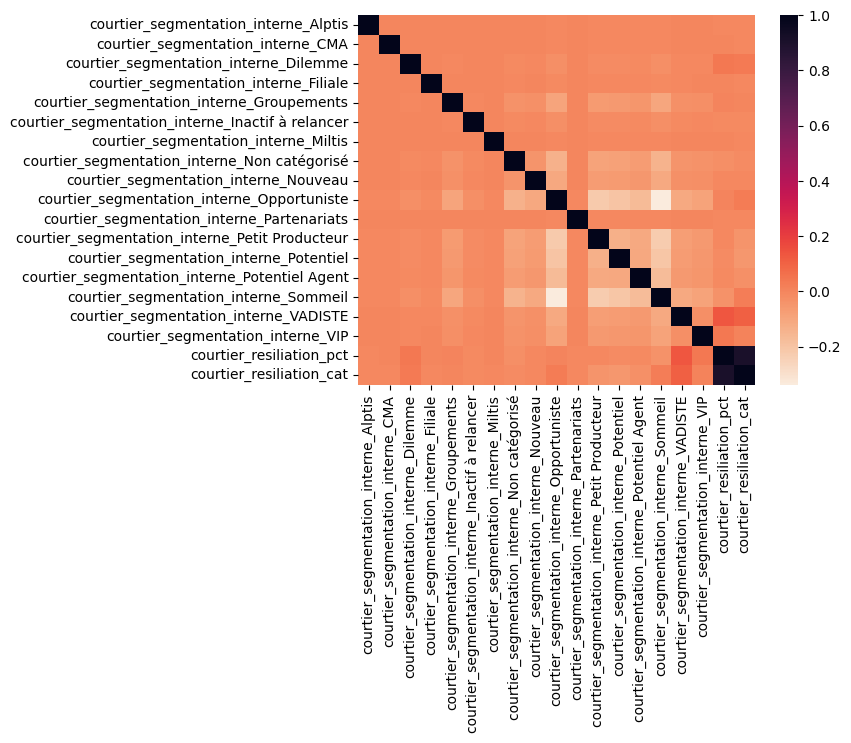

In [95]:
#Correlation between the target and the segmentation typens
df_broker_modified=pd.get_dummies(df_broker, columns=["courtier_reseau_courtage","courtier_segmentation_interne", "courtier_type_commission"],dtype='int')
filtered_columns=[column for column in df_broker_modified.columns if column.startswith("courtier_segmentation_interne")]+["courtier_resiliation_pct", "courtier_resiliation_cat"]
df_broker_filtered= df_broker_modified[filtered_columns]
corr= df_broker_filtered.corr()
sns.heatmap(corr,cmap=sns.cm.rocket_r)

<Axes: >

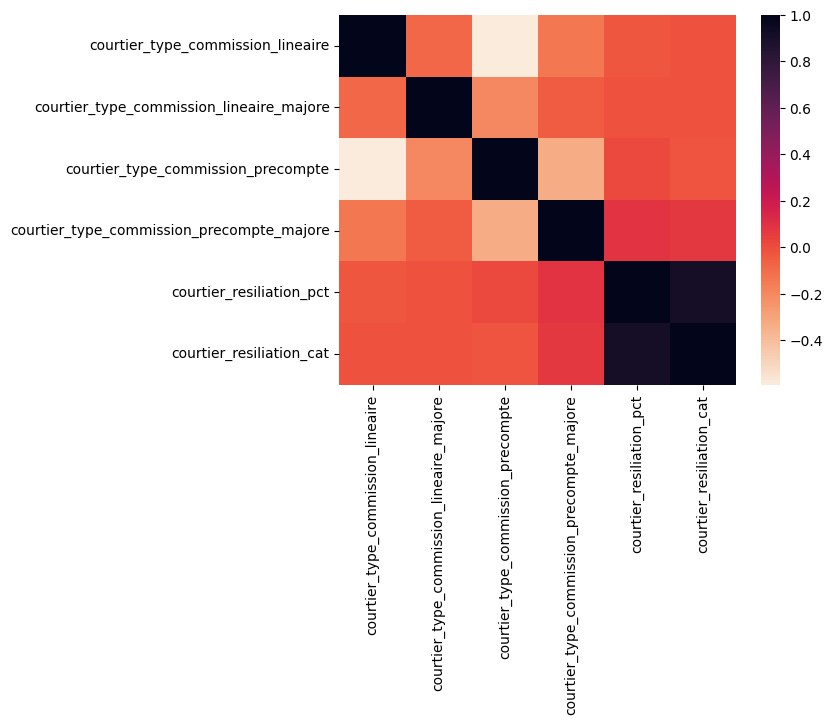

In [99]:
#between the target and the type of commission
filtered_columns=[column for column in df_broker_modified.columns if column.startswith("courtier_type_commission")]+["courtier_resiliation_pct", "courtier_resiliation_cat"]
df_broker_filtered= df_broker_modified[filtered_columns]
corr= df_broker_filtered.corr()
sns.heatmap(corr,cmap=sns.cm.rocket_r)

At first sight, no significant difference concerning the correlation between the internal segmentation and the internal churn rate. But the categories "VADISTE" and "Dilemme" seem to be the most correlated with the targets.
Same for the commission types, with a little bigger correlation for the "precompte majore" type of commission.

In [ ]:
#Number of churn per "type of segmentation"

#Nbr of churn per "type of commission"

df_broker["courtier_resiliation_pct","courtier_nb_client"].groupby("courtier_type_commission").agg({""})

In [103]:
def aggregate_by_commission_type(df_agg):
    """
    Cette fonction agrège les données au niveau du type de commission.
    Chaque ligne représente un type de commission unique avec des statistiques agrégées.
    
    Args:
        df_agg: DataFrame avec les données agrégées par courtier (sortie de aggregate_courtier)
    
    Returns:
        DataFrame agrégé par courtier_type_commission
    """
    
    # Colonnes à sommer
    colonnes_sum = [
        "courtier_nbre_client",
        "courtier_est_escompte",
        "courtier_nb_affaires_n_moins1",
        "courtier_nb_radiations_n_moins1",
        "courtier_nb_affaires_n_moins2",
        "courtier_nb_radiations_n_moins2"
    ]
    
    # Agrégation par type de commission
    df_commission = df_agg.groupby("courtier_type_commission").agg(
        # Nombre de courtiers par type de commission
        nbre_courtiers=("courtier_code_partenaire", "count"),
        
        # Somme des colonnes numériques
        total_clients=("courtier_nbre_client", "sum"),
        total_escompte=("courtier_est_escompte", "sum"),
        total_affaires_n_moins1=("courtier_nb_affaires_n_moins1", "sum"),
        total_radiations_n_moins1=("courtier_nb_radiations_n_moins1", "sum"),
        total_affaires_n_moins2=("courtier_nb_affaires_n_moins2", "sum"),
        total_radiations_n_moins2=("courtier_nb_radiations_n_moins2", "sum"),
        
        # Moyennes
        moy_clients_par_courtier=("courtier_nbre_client", "mean"),
        moy_resiliation_pct=("courtier_resiliation_pct", "mean"),
        moy_anciennete_annees=("courtier_anciennete_annees", "mean"),
        
        # Médianes
        median_clients=("courtier_nbre_client", "median"),
        median_resiliation_pct=("courtier_resiliation_pct", "median"),
        
        # Min/Max
        min_resiliation_pct=("courtier_resiliation_pct", "min"),
        max_resiliation_pct=("courtier_resiliation_pct", "max"),
        
        # Distribution des catégories de résiliation
        nbre_cat_1=("courtier_resiliation_cat", lambda x: (x == 1).sum()),
        nbre_cat_2=("courtier_resiliation_cat", lambda x: (x == 2).sum()),
        nbre_cat_3=("courtier_resiliation_cat", lambda x: (x == 3).sum()),
        nbre_cat_4=("courtier_resiliation_cat", lambda x: (x == 4).sum())
    ).reset_index()
    
    # Calcul de pourcentages supplémentaires
    df_commission["pct_cat_1"] = round(df_commission["nbre_cat_1"] / df_commission["nbre_courtiers"] * 100, 2)
    df_commission["pct_cat_2"] = round(df_commission["nbre_cat_2"] / df_commission["nbre_courtiers"] * 100, 2)
    df_commission["pct_cat_3"] = round(df_commission["nbre_cat_3"] / df_commission["nbre_courtiers"] * 100, 2)
    df_commission["pct_cat_4"] = round(df_commission["nbre_cat_4"] / df_commission["nbre_courtiers"] * 100, 2)
    
    # Arrondir les moyennes
    df_commission["moy_clients_par_courtier"] = df_commission["moy_clients_par_courtier"].round(2)
    df_commission["moy_resiliation_pct"] = df_commission["moy_resiliation_pct"].round(2)
    df_commission["moy_anciennete_annees"] = df_commission["moy_anciennete_annees"].round(2)
    df_commission["median_resiliation_pct"] = df_commission["median_resiliation_pct"].round(2)
    
    return df_commission


# Exemple d'utilisation :
# df_agg = aggregate_courtier(df_portefeuille)
# df_by_commission = aggregate_by_commission_type(df_agg)

In [105]:
aggregate_by_commission_type(df_broker)

,courtier_type_commission,nbre_courtiers,total_clients,total_escompte,total_affaires_n_moins1,total_radiations_n_moins1,total_affaires_n_moins2,total_radiations_n_moins2,moy_clients_par_courtier,moy_resiliation_pct,...,min_resiliation_pct,max_resiliation_pct,nbre_cat_1,nbre_cat_2,nbre_cat_3,nbre_cat_4,pct_cat_1,pct_cat_2,pct_cat_3,pct_cat_4
0,lineaire,981,10991,1068,129717,79004,104146,75543,11.20,7.78,...,0.0,100.0,896,64,5,16,91.34,6.52,0.51,1.63
1,lineaire_majore,134,2605,1566,106472,2574,2576,2862,19.44,7.18,...,0.0,50.0,120,14,0,0,89.55,10.45,0.00,0.00
2,precompte,2819,105503,24104,61509498,37469316,46511374,40118924,37.43,8.96,...,0.0,100.0,2540,224,18,37,90.10,7.95,0.64,1.31
3,precompte_majore,360,11843,8380,981135,244735,441469,127822,32.90,14.32,...,0.0,100.0,288,56,8,8,80.00,15.56,2.22,2.22
